In [76]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [77]:
df = pd.read_csv("../dados/vendas_informatica_100_mil.csv")

df.head()

C:\Users\Karlinha\AppData\Local\Temp\ipykernel_18332\3687366114.py:1: DtypeWarning: Columns (0: Data_Base) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../dados/vendas_informatica_100_mil.csv")


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN


In [78]:
#Criar valor da venda

df["Valor_Venda"] = df["Preco_Unitario"] * df["Qtd"]

df[["Preco_Unitario", "Qtd", "Valor_Venda"]].head()

#Importante: Preco_Unitario não será utilizado como variável de entrada. Ele serve somente para calcular Valor_Venda

,Preco_Unitario,Qtd,Valor_Venda
0,120.0,1,120.0
1,5500.0,1,5500.0
2,1200.0,1,1200.0
3,120.0,2,240.0
4,2200.0,1,2200.0


In [79]:
#Definir entrada e alvo

X = df[["Qtd"]]
y = df["Valor_Venda"]

In [85]:
#Treinar o modelo
modelo = LinearRegression()

modelo.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1985.31]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Qtd']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,19.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [81]:
#Fazer uma previsão

quantidade = [[5]]

previsao = modelo.predict(quantidade)

print(f"Valor previsto para 5 produtos: R$ {previsao[0]:.2f}")

Valor previsto para 5 produtos: R$ 9946.23


c:\Users\Karlinha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#Mostrar a equação encontrada

print(f"Intercepto: R$ {modelo.intercept_:.2f}")
print(f"Coeficiente: R$ {modelo.coef_[0]:.2f}")

Intercepto: R$ 19.70
Coeficiente: R$ 1985.31


Resultado

Para uma venda contendo 5 produtos, o modelo de Regressão Linear Simples estimou um valor de aproximadamente R$ 9.946,23.

Interpretação

O resultado mostra que, utilizando apenas a quantidade de produtos vendidos como variável de entrada, é possível obter uma estimativa do valor da venda. O modelo encontrou uma relação positiva entre essas duas variáveis.

Interpretação para o negócio

No contexto de um e-commerce, essa estimativa pode ser utilizada como uma referência inicial do valor de uma venda com base na quantidade de produtos. Porém, como o modelo considera somente a quantidade, ele não considera diretamente o preço de cada produto, que também influencia o valor final da venda.

In [87]:
#  Gráfico

import matplotlib.pyplot as plt

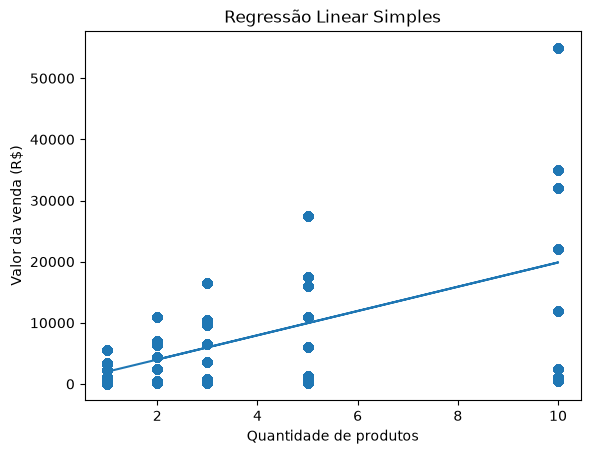

In [88]:
plt.scatter(X, y)
plt.plot(X, modelo.predict(X))
plt.xlabel("Quantidade de produtos")
plt.ylabel("Valor da venda (R$)")
plt.title("Regressão Linear Simples")
plt.show()